In [169]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Sequence

In [170]:
class EmployeeState(TypedDict):
    name: str
    salary: float
    age: int
    decision: Literal["std_hr", "forced_hr"]
    result: str

In [171]:
def analyze_employee(state: EmployeeState) -> EmployeeState:
    """Analyzes the employee's age and salary to determine the HR decision."""
    age = state['age']
    salary = state['salary']
    if age < 30 and salary < 40000:
        state['decision'] = "std_hr"
    else:
        state['decision'] = "forced_hr"
    print(f"LE dossier analysé {state['name']}: Age={age}, Salary={salary}, Decision={state['decision']}")
    return state

In [172]:
def standard_hr_process(state: EmployeeState) -> EmployeeState:
    """Simulates the standard HR process."""
    print(f"Le dossier de {state['name']} a été traité par le HR standard.")
    print("*" * 40)
    state['result'] = f"le dossier de {state['name']} a été traité par le HR standard."
    return state

In [173]:
def forced_hr_process(state: EmployeeState) -> EmployeeState:
    """Simulates the forced HR process."""
    print(f"Le dossier de {state['name']} a été traité par le HR forcé.")
    print("=" * 40)
    state['result'] = f"le dossier de {state['name']} a été traité par le HR forcé."
    return state

In [174]:
def router(state: EmployeeState):
    return state['decision']

In [175]:
workflow = StateGraph(EmployeeState)
workflow.add_node("analyze_node", analyze_employee)
workflow.add_node("standard_hr_node", standard_hr_process)
workflow.add_node("forced_hr_node", forced_hr_process)   
workflow.add_edge(START, "analyze_node")
workflow.add_conditional_edges(
    "analyze_node",
     router, 
    {
        "std_hr": "standard_hr_node",
        "forced_hr": "forced_hr_node"
    }
)
workflow.add_edge("standard_hr_node", END)
workflow.add_edge("forced_hr_node", END)

graph = workflow.compile()


In [176]:
from IPython.display import Image


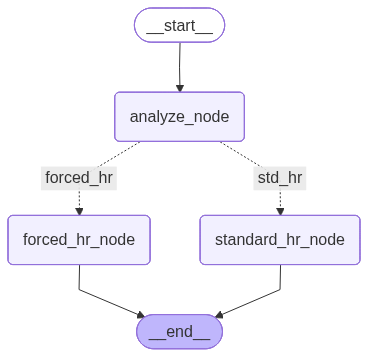

In [177]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [178]:
result = graph.invoke({
    "name": "Alice",
    "age": 28,
    "salary": 35000.0,
    
})

LE dossier analysé Alice: Age=28, Salary=35000.0, Decision=std_hr
Le dossier de Alice a été traité par le HR standard.
****************************************


In [179]:
print("Résultat final:", result)

Résultat final: {'name': 'Alice', 'salary': 35000.0, 'age': 28, 'decision': 'std_hr', 'result': 'le dossier de Alice a été traité par le HR standard.'}


In [180]:
result = graph.invoke({
    "name": "Bob",
    "age": 35,
    "salary": 45000.0,
    
})

LE dossier analysé Bob: Age=35, Salary=45000.0, Decision=forced_hr
Le dossier de Bob a été traité par le HR forcé.


In [181]:
print("Résultat final:", result)

Résultat final: {'name': 'Bob', 'salary': 45000.0, 'age': 35, 'decision': 'forced_hr', 'result': 'le dossier de Bob a été traité par le HR forcé.'}


In [182]:
from langchain.tools import tool

In [183]:
@tool
def add(a: int, b: int):
    """Adds two numbers a and b."""
    print(f"Adding {a} and {b}")
    return a + b

@tool
def multiply(a: int, b: int):
    """Multiplies two numbers a and b."""
    print(f"Multiplying {a} and {b}")
    return a * b

@tool
def divide(a: int, b: int):
    """Divides two numbers a and b."""
    print(f"Dividing {a} by {b}")
    return a / b

@tool
def sub(a: int, b: int):
    """Subtracts two numbers a and b."""
    print(f"Subtracting {b} from {a}")
    return a - b

tools = [add, multiply, divide, sub]    

In [184]:
from typing import Annotated
from langchain.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_core.messages import BaseMessage, AnyMessage
from langgraph.graph import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [185]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [186]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [187]:
load_dotenv(override=True)

True

In [188]:
llm = ChatOpenAI(model="gpt-4o", temperature=0.6)
llm_with_tools = llm.bind_tools(tools=tools)

In [189]:
def assistant(state: AgentState) -> AgentState:
    """Simulates an assistant that processes messages."""
    response = llm_with_tools.invoke(state['messages'])
    print("*" * 40)
    print("LLM invoked")
    return {"messages": [response]}

In [190]:
def should_continue(state: AgentState):
    """Determines if the assistant should use the add tool."""
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "continue"
    else:
        return "end"
    

In [191]:
from langgraph.prebuilt import ToolNode

In [197]:
workflow = StateGraph(AgentState)
workflow.add_node("assistant_node", assistant)
workflow.set_entry_point("assistant_node")
workflow.add_node("tools", ToolNode(tools=tools))
workflow.add_conditional_edges(
    "assistant_node",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)
workflow.add_edge("tools", "assistant_node")
memory= InMemorySaver()
graph = workflow.compile(checkpointer=memory)

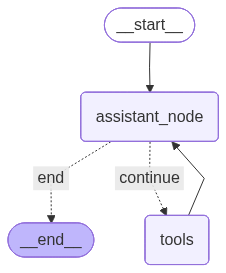

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [198]:
config = {"configurable":{"thread_id": "1"}}
result = graph.invoke({
    "messages": [
        HumanMessage(content="Ajoute 5 à 43 et multiplie le résultat par 2 puis donne moi un proverbe en arabe"),
    ]
}, config=config)

****************************************
LLM invoked
Adding 43 and 5
Multiplying 48 and 2
****************************************
LLM invoked


In [199]:
print("Résultat final:", result['messages'][-1].content)

Résultat final: Le résultat de l'ajout de 5 à 43 est 48, et en le multipliant par 2, on obtient 96.

Un proverbe en arabe : "الصبر مفتاح الفرج" qui signifie "La patience est la clé de la délivrance".


In [201]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="Je m'appelle Diego Maradona"),
    ]
}, config=config)

****************************************
LLM invoked


In [ ]:
print("Résultat final:", result['messages'][-1].content)

Résultat final: Bonjour Diego Maradona ! Comment puis-je vous aider aujourd'hui ?


In [202]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="comment je m'appelle ?"),
    ]
}, config=config)

****************************************
LLM invoked


In [203]:
print("Résultat final:", result['messages'][-1].content)

Résultat final: Vous m'avez dit que vous vous appelez Diego Maradona.
